|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">A deep understanding of AI language model mechanisms</a></h1>|
|-|:-:|
|<h2>Part 2:</h2>|<h1>Large language models<h1>|
|<h2>Section:</h2>|<h1>Pretrain LLMs<h1>|
|<h2>Lecture:</h2>|<h1><b>CodeChallenge HELPER: SGD vs. Adam vs. AdamW<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">udemy.com/course/dullms_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# vector plots
import matplotlib_inline.backend_inline

In [2]:
# matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
print("hi")

hi


# Pre-exercise example

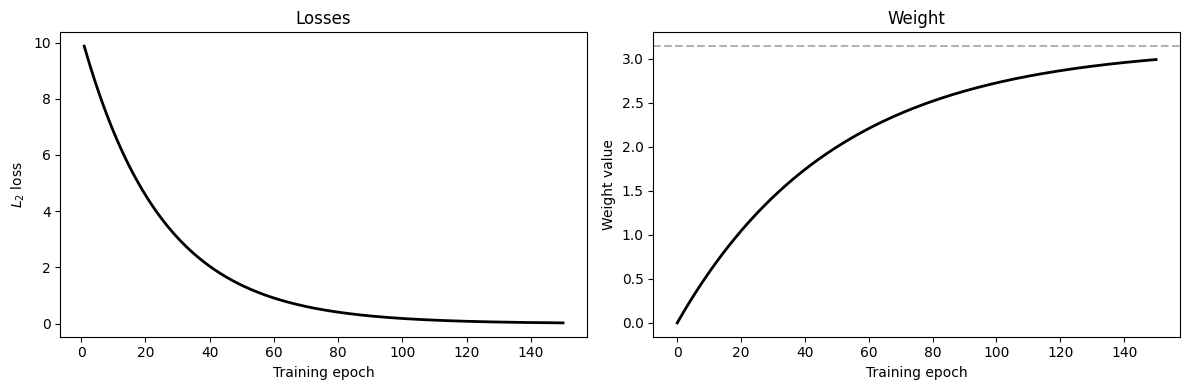

In [7]:
# initialize weight value
w = torch.tensor([0.], requires_grad=True)

# target value
target = torch.tensor([torch.pi])

# learning rate
lr = .01

# create the optimizers
optimizer = torch.optim.SGD([w],lr=lr)

# number of training iterations
numIters = 150

# initialize results matrices
all_losses  = np.zeros(numIters)
all_weights = np.zeros(numIters+1)
all_weights[0] = w.item() # initial value


### training loop
for i in range(numIters):

  # train the weight
  optimizer.zero_grad()
  loss = (w - target)**2
  loss.backward()
  optimizer.step()

  # store the loss and update the weight value
  all_losses[i] = loss.item()
  all_weights[i+1] = w.item()



#### visualization
_,axs = plt.subplots(1,2,figsize=(12,4))

# plot the losses and weight values
axs[0].plot(range(1,numIters+1),all_losses,'k',linewidth=2)
axs[1].plot(range(0,numIters+1),all_weights,'k',linewidth=2)

axs[0].set(title='Losses',ylabel='$L_2$ loss',xlabel='Training epoch')
axs[1].set(title='Weight',ylabel='Weight value',xlabel='Training epoch')
axs[1].axhline(target,linestyle='--',color=[.7,.7,.7],label='Target')

plt.tight_layout()
plt.show()

# Exercise 1: The optimizer competition :0

In [12]:
# initialize weight value
wSGD   = torch.tensor([2.], requires_grad=True)
wAdam  = torch.tensor([2.], requires_grad=True)
wAdamW = torch.tensor([2.], requires_grad=True)

# target value
target = torch.tensor([5.])

# learning rates (equal for exercises 1&3; changed in exercise 2)
learningrateSGD = 0.05
learningrateAdm = 0.05
learningrateAdmW = 0.05

# create the optimizers
optimizerSGD   = torch.optim.SGD([wSGD],    lr=learningrateSGD)
optimizerAdam  = torch.optim.Adam([wAdam], lr=learningrateAdm)
optimizerAdamW = torch.optim.AdamW([wAdamW], lr=learningrateAdmW)

# number of training iterations
numIters = 150

# initialize results matrices

all_losses  = np.zeros((3, numIters))

all_weights = np.zeros((3, numIters))
all_weights[:,0] = wSGD.item() # pluck out the number from the pytorch overhead


# training loop
for i in range(numIters):

  # train the SGD weight
  # optimizerSGD.zero_grad()
  lossSGD = (wSGD - target)**2
  lossSGD.backward()
  optimizerSGD.step()
  print(f"wSGD Gradients: {wSGD.grad}")

  # train with Adam
  # optimizerAdam.zero_grad()
  lossAdam = (wAdam - target)**2
  lossAdam.backward()
  optimizerAdam.step()
  print(f"wAdam Gradients: {wAdam.grad}")

  # train with AdamW
  optimizerAdamW.zero_grad()
  lossAdamW = (wAdamW - target)**2
  lossAdamW.backward()
  optimizerAdamW.step()
  print(f"wAdamW Gradients: {wAdamW.grad}\n")


  # store the losses and updated weight value
  all_losses[0,i] = lossSGD.item() # loss from SGD
  all_losses[1,i] = lossAdam.item() # from Adam
  all_losses[2,i] = lossAdamW.item() # from AdamW

  all_weights[0,i] = wSGD.item() # weight value from SGD
  all_weights[1,i] = wAdam.item() # from Adam
  all_weights[2,i] = wAdamW.item() # from AdamW

wSGD Gradients: tensor([-6.])
wAdam Gradients: tensor([-6.])
wAdamW Gradients: tensor([-6.])

wSGD Gradients: tensor([-11.4000])
wAdam Gradients: tensor([-11.9000])
wAdamW Gradients: tensor([-5.9020])

wSGD Gradients: tensor([-15.6600])
wAdam Gradients: tensor([-17.7034])
wAdamW Gradients: tensor([-5.8041])

wSGD Gradients: tensor([-18.3540])
wAdam Gradients: tensor([-23.4108])
wAdamW Gradients: tensor([-5.7063])

wSGD Gradients: tensor([-19.2126])
wAdam Gradients: tensor([-29.0221])
wAdamW Gradients: tensor([-5.6087])

wSGD Gradients: tensor([-18.1499])
wAdam Gradients: tensor([-34.5364])
wAdamW Gradients: tensor([-5.5113])

wSGD Gradients: tensor([-15.2723])
wAdam Gradients: tensor([-39.9528])
wAdamW Gradients: tensor([-5.4141])

wSGD Gradients: tensor([-10.8674])
wAdam Gradients: tensor([-45.2702])
wAdamW Gradients: tensor([-5.3171])

wSGD Gradients: tensor([-5.3758])
wAdam Gradients: tensor([-50.4876])
wAdamW Gradients: tensor([-5.2205])

wSGD Gradients: tensor([0.6534])
wAdam Grad

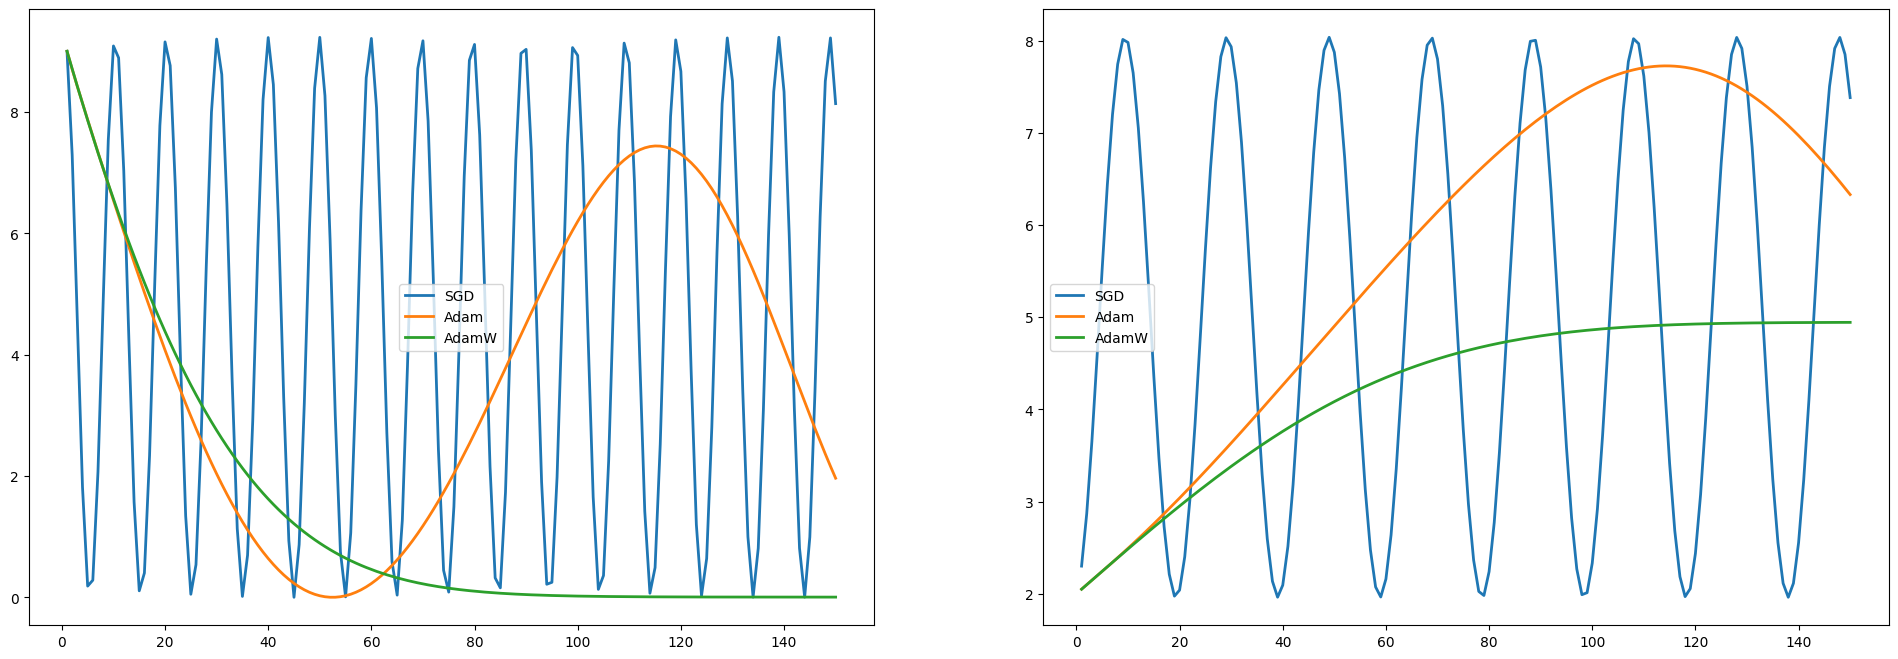

In [13]:

# labels and markers
optimlabels = [ 'SGD','Adam','AdamW' ]
markercols = [ [.7,.7,.9],[.7,.9,.7],[.9,.7,.7] ]
shapes = 'so^'


_,axs = plt.subplots(1,2,figsize=(24,8))

# plot the losses and weight values
# axs[0].plot(range(1,numIters+1),all_losses,'k',linewidth=2)
# axs[1].plot(range(0,numIters+1),all_weights,'k',linewidth=2)

# axs[0].set(title='Losses',ylabel='$L_2$ loss',xlabel='Training epoch')
# axs[1].set(title='Weight',ylabel='Weight value',xlabel='Training epoch')
# axs[1].axhline(target,linestyle='--',color=[.7,.7,.7],label='Target')
# loop over the optimizers and plot

for i in range(3):
    axs[0].plot(range(1, numIters+1), all_losses[i], linewidth=2, label=optimlabels[i])
    axs[1].plot(range(1, numIters+1), all_weights[i], linewidth=2, label=optimlabels[i])

 
  # plot the losses


  # plot the weight


# axs[0].set(title='Losses',ylabel='$L_2$ loss',xlabel='Training epoch')
# axs[1].set(

axs[0].legend()
axs[1].legend()
# plt.tight_layout()
# plt.show()

# Exercise 2: Adjust the learning rates

# Exercise 3: Without resetting gradients